<a href="https://colab.research.google.com/github/bzhuang2-create/SURF---MC-Simulation-for-Educational-Research/blob/main/MC_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# @title ASE and ipywidgets Install
%pip install ase
%pip install -q ipywidgets

In [43]:
# @title Imports and Constants
import ase
from ase import Atoms, Atom
from ase.calculators.lj import LennardJones as LJ
from ase.geometry.rdf import get_rdf
from ase.io import write
from ase.neighborlist import NeighborList

import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

import numpy as np
import random
from tqdm import tqdm
import pandas as pd

from numba import njit, types
from numba.typed import Dict

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual, Layout
from IPython.display import clear_output

kB = 8.617e-5  # eV/K

In [5]:
# @title Lennard Jones Parameters

'''
The cantor pairing function, which maps two positive integers to a unique integer. Useful for quick data lookup for various species

Note: order matters, but subsequent definition of the property arrays give the correct properties regardless of order
a: first integer
b: second integer

returns: a unique integer
'''
@njit(fastmath=True)
def cantor_pair(a, b):
  return int(((a + b) * (a + b + 1)) // 2 + b)

'''
This is a dictionary setup using numba. Not used directly in the Monte Carlo simulation, but useful to set up the cantor pairing function array
'''

# Lennard-Jones parameter dictionary
LJ_dict = Dict.empty(key_type = types.unicode_type, value_type = types.UniTuple(types.float64, 3))

# Order: atomic number, sigma, epsilon
LJ_dict['Au'] = (79, 3.4, 0.10423)
LJ_dict['Ag'] = (47, 3.4, 0.10423)
LJ_dict['H'] = (1, 3.4, 0.10423)
LJ_dict['C'] = (6, 3.4, 0.10423)


'''
This is the cantor pairing function array. It stores the average LJ parameters for each pair of species as sigma ** 6 and (4)epsilon to reduce computation later.
If more species are needed, the length of the array can simply be extended
'''
LJ_avg_array = np.zeros((15000, 2), dtype=np.float64)  # (sigma^6, 4*epsilon)

for key1 in LJ_dict.keys():
  for key2 in LJ_dict.keys():
    number1, sigma1, epsilon1 = LJ_dict[key1]
    number2, sigma2, epsilon2 = LJ_dict[key2]
    LJ_avg_array[cantor_pair(number1, number2)] = (((sigma1 + sigma2) / 2) ** 6, 4 * np.sqrt(epsilon1 * epsilon2))

#https://datagrid.hu/boda/Boda-sajat/Rush/Books/Frenkel.pdf

'''
A function to calculate the Lennard-Jones interaction energy between two atoms

r2: the squared distance between the two atoms (A^2)
atom1: the atomic symbol for the first atom
atom2: the atomic symbol for the second atom
lj_avg_array: a long array of average LJ parameters. Indexed using a pairing function, which is faster than accessing a dictionary

returns: the interaction energy between the two atoms (eV)
'''
@njit(fastmath = True)
def lennard_jones(r2, atom1, atom2, lj_avg_array):
  sigma_6, epsilon_4 = lj_avg_array[cantor_pair(atom1, atom2)]
  #sigma ** 6 and (4)epsilon

  return epsilon_4 * (((sigma_6 ** 2) / (r2 ** 6)) - (sigma_6 / (r2 ** 3)))


In [6]:
# @title Single and Total Energy Calculations
'''
Calculates all interaction energies for a single atom, excluding itself

atom_numbers: list of atomic numbers
atom_positions: list of atomic positions
no_atoms: total number of atoms
box_length: length of the cube (A)
selected: the index of the atom to calculate energies for
energy_fxn: a function to calculate pairwise interaction energies. Must be of the form fxn(radius, atom#1, atom#2, params)
params: any additional parameters the user-specified energy function needs

returns: the total interaction energies for a single atom
'''
@njit(fastmath = True)
def single_energy(atom_numbers, atom_positions, no_atoms, box_length, selected, energy_fxn, params):
  # Calculates the interaction energies for a selected atom

  energy = 0
  for i in range(no_atoms):
    if(i != selected):
      fixed_position = atom_positions[selected]
      other_position = atom_positions[i]

      dx = fixed_position[0] - other_position[0]
      dy = fixed_position[1] - other_position[1]
      dz = fixed_position[2] - other_position[2]

      # enforce periodic boundary conditions
      dx -= box_length * round(dx / box_length)
      dy -= box_length * round(dy / box_length)
      dz -= box_length * round(dz / box_length)
      r2 = (dx*dx + dy*dy + dz*dz)

      energy += energy_fxn(r2, atom_numbers[selected], atom_numbers[i], params)

  return energy

'''
Calculates the total energy of the system by finding all pairwise interaction energies and dividing by 2 to avoid double-counting

atom_numbers: list of atomic numbers
atom_positions: list of atomic positions
no_atoms: total number of atoms
box_length: length of the cube (A)
energy_fxn: a function to calculate pairwise interaction energies. Must be of the form fxn(radius, atom#1, atom#2, params)
params: any additional parameters the user-specified energy function needs

returns: the total interaction energies for a system
'''
@njit(fastmath = True)
def total_energy(atom_numbers, atom_positions, no_atoms, box_length, energy_fxn, params):
  energy = 0
  for i in range(no_atoms):
    energy += single_energy(atom_numbers, atom_positions, no_atoms, box_length, i, energy_fxn, params)

  return energy / 2

In [44]:
# @title Pressure Calculations and Partial RDFs

'''
Converts a distance to a bin index for an RDF

distance: the distance to convert
R_bins: a list of distances corresponding to the RDF
'''
def distance_to_bin(distance, R_bins):
  single_radius = R_bins[1] - R_bins[0]
  # this assumes there are at least two bins, which there should be if the slider minimums are appropriate

  index = np.floor(distance / single_radius)
  #print(f"the bin index is {index}")

  return int(index)



# does direction matter?
# how many iterations should I sample for pressure?
'''
Generates a partial RDF for a specific pair of species in the system

selected_species: the atomic symbol for the first atom
target_species: the atomic symbol for the second atom
species_list: list of names of atoms (ex. ['H', 'H', 'C'])
no_atoms: total number of atoms
atom_positions: list of atomic positions, corresponding to species_list
box_length: length of the cube (A)
R_bins: a list of distances corresponding to the RDF
'''

def partial_RDF(selected_species, target_species, species_list, no_atoms, atom_positions, box_length, R_bins):

  histogram = np.zeros(len(R_bins))
  select_count = 0

  #print(f"the species list is {species_list}")
  #print(f"the selected species is {selected_species}")

  for i in range(no_atoms):
    if(species_list[i] == selected_species):
      selected_position = atom_positions[i]
      select_count += 1

      for j in range(no_atoms):
        if(species_list[j] == target_species):
          target_position = atom_positions[j]

          dx = selected_position[0] - target_position[0]
          dy = selected_position[1] - target_position[1]
          dz = selected_position[2] - target_position[2]

          dx -= box_length * round(dx / box_length)
          dy -= box_length * round(dy / box_length)
          dz -= box_length * round(dz / box_length)

          distance = np.sqrt(dx*dx + dy*dy + dz*dz)
          index = distance_to_bin(distance, R_bins)
          histogram[index] += 1

  return histogram / max(select_count, 1)

# WIP
# technically there is a tighter distance bound here (consider changing)
def bins_to_distance(box_length, no_bins):
  distances = np.zeros(no_bins + 1)
  for i in range(no_bins):
    distances[i] = i * box_length / no_bins

  return distances


'''
Calculates the various integrands of the pressure equation

atom1: atomic number of the first atom type
atom2: atomic number of the second atom type
RDF: a list corresponding to the RDF for the specific atom1/atom2 combination
R_bins: a list of distances corresponding to the RDF
energy_fxn: a function to calculate pairwise interaction energies. Must be of the form fxn(radius, atom#1, atom#2, params)
params: any additional parameters the user-specified energy function needs
'''
def pressure_equation(atom1, atom2, RDF, R_bins, energy_fxn, params):

  sum = 0

  for i in range(len(R_bins) - 1):
    r1 = R_bins[i]
    r2 = R_bins[i + 1]

    r_avg = (r1 + r2) / 2
    rp1 = r1 + 1e-3
    rn1 = r1 - 1e-3

    rp2 = r2 + 1e-3
    rn2 = r2 - 1e-3

    # very bootleg, unless the derivative's preciseness is extremely important (in which case I can reduce the step sizes)
    dEdr2 = (energy_fxn(rp2, atom1, atom2, params) - energy_fxn(rn2, atom1, atom2, params)) / (rp2 - r_avg)
    dEdr1 = (energy_fxn(rp1, atom1, atom2, params) - energy_fxn(rn1, atom1, atom2, params)) / (r_avg - rn1)

    gr2 = RDF[i + 1]
    gr1 = RDF[i]

    total2 = r2 ** 3 * gr2 * dEdr2
    total1 = r1 ** 3 * gr1 * dEdr1

    sum += (total1 + total2) * (r2 - r1) / 2


  return sum

# which mol fraction(s) do I multiply by?
'''
Given a species string and a fraction_list tuple, find the mol fraction of species

fraction_list: list of tuples of the type (Atomic Symbol, Mol Fraction)
species: string of the species to find the fraction of
'''
def find_fractions(fraction_list, species):
  for i in range(len(fraction_list)):
    if(fraction_list[i][0] == species):
      return fraction_list[i][1]

  return -1

'''
Generates all partial RDFs for the various species in the system

species_list: list of names of atoms (ex. ['H', 'H', 'C'])
no_atoms: total number of atoms
atom_positions: list of atomic positions, corresponding to species_list
box_length: length of the cube (A)
'''
def generate_partial_RDFs(species_list, no_atoms, atom_positions, atom_numbers, box_length, no_bins):
  unique_species = (pd.unique(pd.Series(species_list)))
  unique_numbers = (pd.unique(pd.Series(atom_numbers)))

  RDF_package = []
  R_bins = bins_to_distance(box_length, no_bins)

  for i in range(len(unique_species)):
    for j in range(i, len(unique_species)):
      species1 = unique_species[i]
      species2 = unique_species[j]

      number1 = unique_numbers[i]
      number2 = unique_numbers[j]

      print(f"the species are {species1} and {species2}")
      print(f"the numbers are {number1} and {number2}")

      RDF = partial_RDF(species1, species2, species_list, no_atoms, atom_positions, box_length, R_bins)
      RDF_package.append((species1, species2, number1, number2, RDF))

  return RDF_package, R_bins


# should different densities be used?
'''
Calculates the pressure of a system according to the pressure equation (integral with RDFs)

fraction list: list of tuples of the type (Atomic Symbol, Mol Fraction)
density: number density of the atoms (atoms per A^3)
temperature: temperature (K)
species_list: list of names of atoms (ex. ['H', 'H', 'C'])
no_atoms: total number of atoms
atom_positions: list of atomic positions, corresponding to species_list
atom_numbers: list of atomic numbers, corresponding to species_list
box_length: length of the cube (A)
no_bins: number of bins for the RDF
'''
def calculate_pressure(fraction_list, density, temperature, species_list, no_atoms, atom_positions, atom_numbers, box_length, no_bins, energy_fxn, params):
  RDF_package, R_bins = generate_partial_RDFs(species_list, no_atoms, atom_positions, atom_numbers, box_length, no_bins)

  sum = 0
  constant = density * kB * temperature

  for i in range(len(RDF_package)):
    species1, species2, number1, number2, RDF = RDF_package[i]
    integral = pressure_equation(number1, number2, RDF, R_bins, energy_fxn, params)

    fraction1 = find_fractions(fraction_list, species1)
    fraction2 = find_fractions(fraction_list, species2)
    sum += integral * fraction1 * fraction2

  return constant - (2 / 3) * np.pi * density * density * sum


In [39]:
# @title Simulation Helpers and Initialization
'''
Converts a given number of atoms and number density to the corresponding cube length

no_atoms: total number of atoms
rho: density (atoms per A^3)
returns: the length of the cube (A)
'''
@njit(fastmath = True)
def density_to_length(no_atoms, rho):
  # rho: atoms per A^3
  Volume = no_atoms / rho
  Length = np.cbrt(Volume)
  return Length

'''
Initializes an ASE Atoms object for the Monte Carlo Simulation

no_atoms: total number of atoms
length: length of the cube
species: list of tuples of the type (Atomic Symbol, Mol Fraction)
'''
def initialize_atoms(no_atoms, length, species):
  positions = ((np.random.rand(no_atoms, 3)) * length)

  species_string = ""
  for i in range(len(species)):
    species_string += species[i][0] * int(species[i][1] * no_atoms)

  MC = Atoms(species_string, positions, cell = [length, length, length], pbc = [True, True, True])
  return MC

'''
Initializes the monte Carlo simulation

no_atoms: total number of atoms
density: number density of the atoms (atoms per A^3)
species: list of tuples of the type (Atomic Symbol, Mol Fraction)
returns: an ASE Atoms object, with all atoms placed in random locations inside the box
'''
def MC_initial(no_atoms, density, species):
  length = density_to_length(no_atoms, density)
  atoms = initialize_atoms(no_atoms, length, species)
  return atoms

'''
Creates a unit vector pointing in a random direction
returns: a numpy array serving as the unit vector
'''
@njit(fastmath=True)
def unit():
  vector = np.array([np.random.uniform(-1, 1), np.random.uniform(-1, 1), np.random.uniform(-1, 1)])
  return vector / np.linalg.norm(vector)

In [40]:
# @title Main Function
'''
The main function which implmentes the Monte Carlo simulation according to the Metropolis algorithm
Volume, number of atoms, and temperature are fixed. Periodic boundary conditions are used.

density: number density of the atoms (atoms per A^3)
no_atoms: total number of atoms
species: list of tuples of the type (Atomic Symbol, Mol Fraction)
iterations: the mnaximum number of iterations the  simulation will complete
temperature: temperature (K)
energy: a function to calculate pairwise interaction energies. Must be of the form fxn(radius, atom#1, atom#2, params)
params: any additional parameters the user-specified energy function needs
n_warmup: after this many iterations, the simulation is assumed to be at equilibrium
'''
def MC_main(density, no_atoms, species, iterations, temperature, energy = None, params = (3.4, 0.010423, 3.4, 0.010423), n_warmup = 1000000):
  MC = MC_initial(no_atoms, density, species)

  energy_fxn = None
  if(energy is None):
    energy_fxn = lennard_jones
    #MC.calc = LennardJones(parameters = LJ_calc_dict)
  else:
    energy_fxn = energy

  length = density_to_length(no_atoms, density)
  step_size = length / 10
  # what is a good step size?
  '''
  fig, ax = plt.subplots()
  plot_atoms(MC, ax, rotation='45x,45y,45z', radii = .4)
  plt.show()
  '''
  atom_names = MC.get_chemical_symbols()
  atom_numbers = MC.get_atomic_numbers()

  prev_energy = 1e99
  frames = []
  energy_array = []
  current_position = MC.get_positions()

  total_state_energy = total_energy(atom_numbers, current_position, no_atoms, length, energy_fxn, params)
  #print(total_state_energy)

  for i in tqdm(range(iterations)):
    selected_atom = random.randrange(0, no_atoms, 1)
    current_energy = single_energy(atom_numbers, current_position, no_atoms, length, selected_atom, energy_fxn, params)

    vector = unit() * step_size * np.random.rand()
    new_position = current_position.copy()

    new_position[selected_atom] += vector
    new_position[selected_atom] %= length

    new_energy = single_energy(atom_numbers, new_position, no_atoms, length, selected_atom, energy_fxn, params)
    energy_difference = new_energy - current_energy


    if(i > n_warmup):
      energy_array.append(total_state_energy)

    if(energy_difference <= 0):
      current_position = new_position.copy()
      total_state_energy += energy_difference
    else:
      probability = np.exp(-((energy_difference) / (kB * temperature)))
      if(np.random.rand() < probability):
        current_position = new_position.copy()
        total_state_energy += energy_difference
      else:
        pass

    if i % 10000 == 0:
      MC.set_positions(current_position)
      frame = MC.copy()
      frame.info["step"] = i
      frame.info["temperature"] = temperature
      frames.append(frame)

  no_bins = int(15 * length)
  RDF, R_bins = get_rdf(MC, length / 2.01, nbins = no_bins)

  # consider changing or removing this
  write("output.extxyz", frames)

  pressure = calculate_pressure(species, density, temperature, atom_names, no_atoms, current_position, atom_numbers, length, no_bins, energy_fxn, params)

  Cv = (np.var(energy_array)) / (kB * temperature * temperature)
  Cv_convert = Cv * 1.602e11 # Original Cv is in eV / A^3, now in J / m^3

  return (MC, RDF, R_bins, no_bins)


In [9]:
# @title Button Wrapper Function

fraction_list = [('Au', 0.25), ('Ag', 0.25), ('C', 0.25), ('H', 0.25)]

'''
A wrapper function for the button. Runs the MC simulation according to what is inside of the function and loops
'''
def run_MC(null_filler = None):
  clear_output()

  Ns = np.linspace(N_slider.value[0], N_slider.value[1], atom_sweep_slider.value)
  for i in range(len(Ns)):
    Ns[i] = int(Ns[i])

  rhos = np.linspace(rho_slider.value[0], rho_slider.value[1], rho_sweep_slider.value)

  temperature = temp_slider.value

  niterations = iteration_slider.value[1]
  nwarmup = iteration_slider.value[0]

  fig1, axs1 = plt.subplots(len(rhos), len(Ns), figsize=(16, 12), sharex=True, sharey=True)
  fig1.suptitle('Radial Distribution Functions', fontsize=18)
  fig1.supxlabel('Distance (A)')
  fig1.supylabel('Radial Distribution Function')

  print("Running MC Simulation")

  for i in (range(len(rhos))):
    for j in range(len(Ns)):
      rho = rhos[i]
      N = int(Ns[j])

      total = (N // 4) * 4
      # placeholder, will need custom string later

      Result = MC_main(rho, total, fraction_list, niterations, temperature, params = LJ_avg_array, n_warmup = nwarmup)
      MC, RDF, R_bins, no_bins = Result

      # code to plot the RDFs for each iteration
      ax_c = axs1[i, j]
      ax_c.plot(R_bins, RDF, label = f"N = {N}, rho = {rho}")
      ax_c.set_title(f"N = {N}, rho = {rho}")
      ax_c.autoscale(enable = True, axis = 'both', tight = False)

  plt.tight_layout()
  plt.show()
  rebuild_objects()

Running MC Simulation


100%|██████████| 200000/200000 [00:13<00:00, 14384.37it/s]
/tmp/ipykernel_29469/3964401070.py:138: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_species = (pd.unique(species_list))


the species are Au and Au
the numbers are 79 and 79
the species are Au and Ag
the numbers are 79 and 47
the species are Au and C
the numbers are 79 and 6
the species are Au and H
the numbers are 79 and 1
the species are Ag and Ag
the numbers are 47 and 47
the species are Ag and C
the numbers are 47 and 6
the species are Ag and H
the numbers are 47 and 1
the species are C and C
the numbers are 6 and 6
the species are C and H
the numbers are 6 and 1
the species are H and H
the numbers are 1 and 1


100%|██████████| 200000/200000 [00:15<00:00, 12695.02it/s]


the species are Au and Au
the numbers are 79 and 79
the species are Au and Ag
the numbers are 79 and 47
the species are Au and C
the numbers are 79 and 6
the species are Au and H
the numbers are 79 and 1
the species are Ag and Ag
the numbers are 47 and 47
the species are Ag and C
the numbers are 47 and 6
the species are Ag and H
the numbers are 47 and 1
the species are C and C
the numbers are 6 and 6
the species are C and H
the numbers are 6 and 1
the species are H and H
the numbers are 1 and 1


...

the species are Au and Au
the numbers are 79 and 79
the species are Au and Ag
the numbers are 79 and 47
the species are Au and C
the numbers are 79 and 6
the species are Au and H
the numbers are 79 and 1
the species are Ag and Ag
the numbers are 47 and 47
the species are Ag and C
the numbers are 47 and 6
the species are Ag and H
the numbers are 47 and 1
the species are C and C
the numbers are 6 and 6
the species are C and H
the numbers are 6 and 1
the species are H and H
the numbers are 1 and 1


100%|██████████| 200000/200000 [00:15<00:00, 12610.25it/s]


the species are Au and Au
the numbers are 79 and 79
the species are Au and Ag
the numbers are 79 and 47
the species are Au and C
the numbers are 79 and 6
the species are Au and H
the numbers are 79 and 1
the species are Ag and Ag
the numbers are 47 and 47
the species are Ag and C
the numbers are 47 and 6
the species are Ag and H
the numbers are 47 and 1
the species are C and C
the numbers are 6 and 6
the species are C and H
the numbers are 6 and 1
the species are H and H
the numbers are 1 and 1


100%|██████████| 200000/200000 [00:18<00:00, 11027.85it/s]


the species are Au and Au
the numbers are 79 and 79
the species are Au and Ag
the numbers are 79 and 47
the species are Au and C
the numbers are 79 and 6
the species are Au and H
the numbers are 79 and 1
the species are Ag and Ag
the numbers are 47 and 47
the species are Ag and C
the numbers are 47 and 6
the species are Ag and H
the numbers are 47 and 1
the species are C and C
the numbers are 6 and 6
the species are C and H
the numbers are 6 and 1
the species are H and H
the numbers are 1 and 1


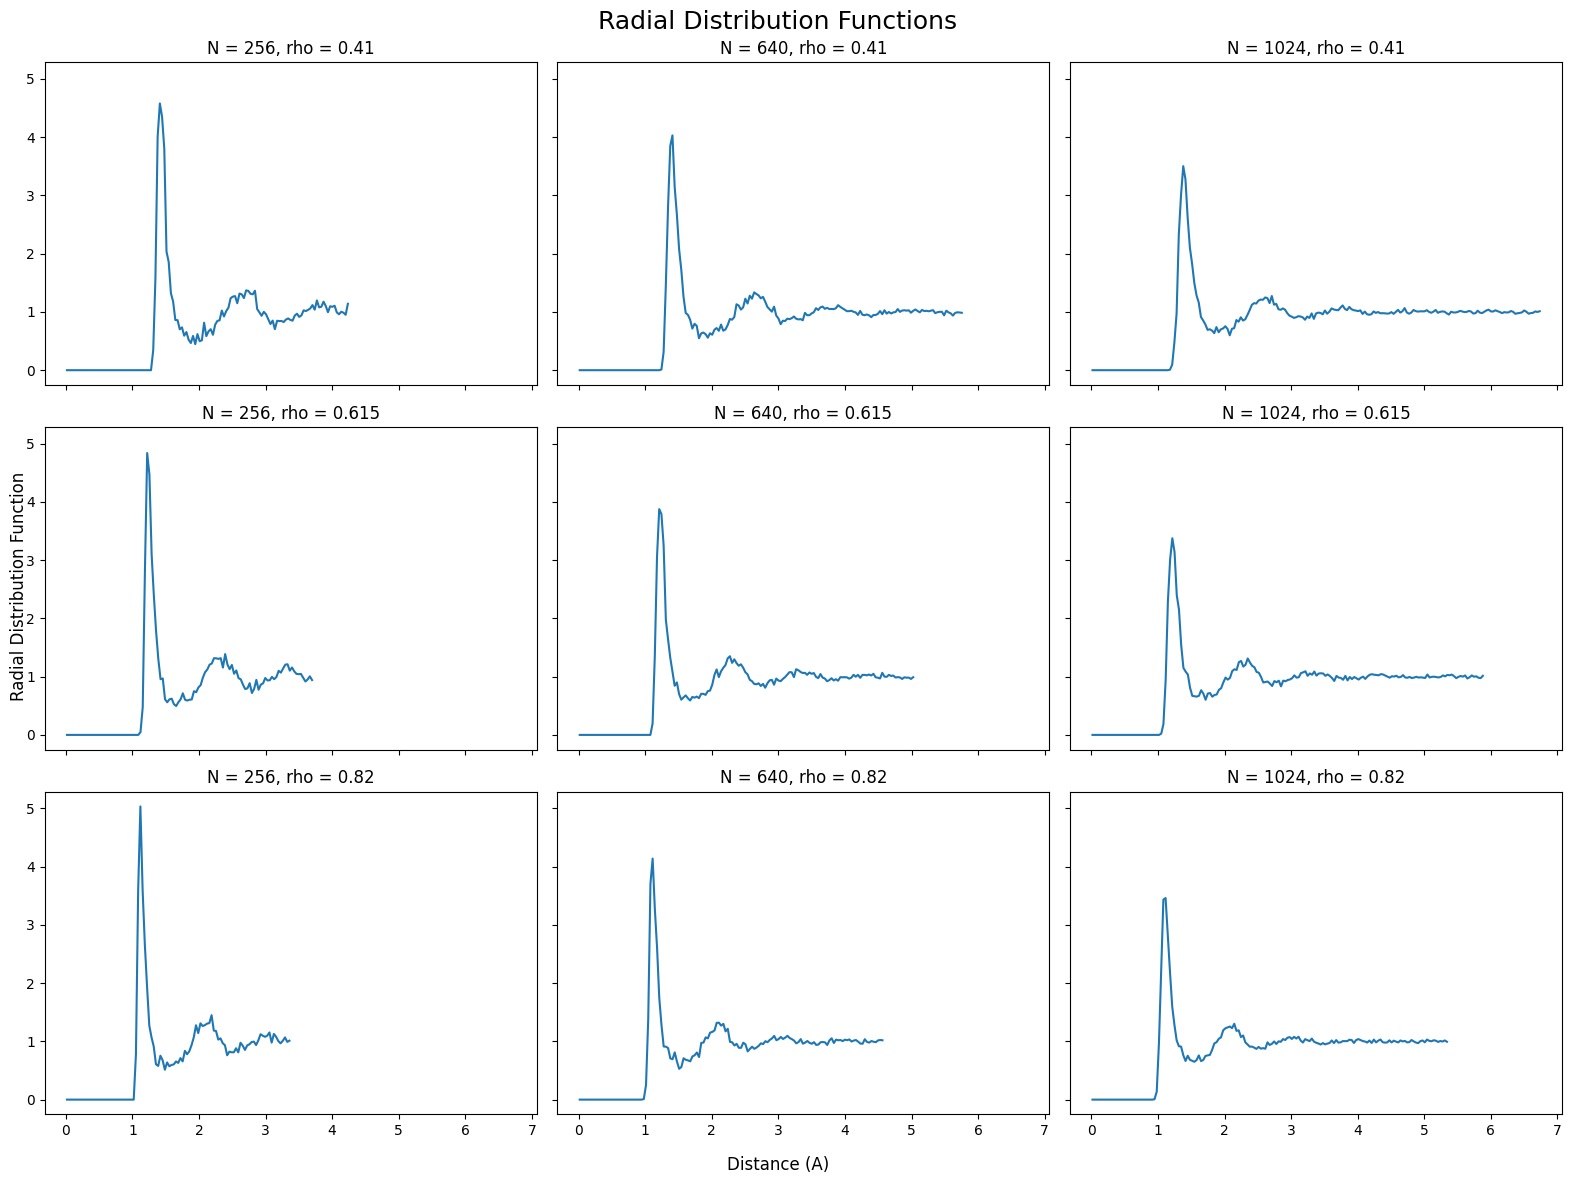

Button(description='Run MC Simulation', icon='check', style=ButtonStyle(), tooltip='Run MC Simulation')

IntRangeSlider(value=(256, 1024), description='Atoms:', layout=Layout(width='400px'), max=2048, min=128, step=…

IntSlider(value=3, continuous_update=False, description='Atom Sweep:', layout=Layout(width='400px'), max=5, mi…

FloatRangeSlider(value=(0.41, 0.82), description='Density:', layout=Layout(width='400px'), max=1.0, min=0.01, …

IntSlider(value=3, continuous_update=False, description='Density Sweep:', layout=Layout(width='400px'), max=5,…

IntSlider(value=200, continuous_update=False, description='Temperature:', layout=Layout(width='400px'), max=40…

IntRangeSlider(value=(100000, 200000), description='Iterations:', layout=Layout(width='400px'), max=10000000, …

In [45]:
# @title UI Code
style = {'description_width': '100px'}
width = '400px'

N_slider = widgets.IntRangeSlider(
    value = [256, 1024],        # initial range [min_selected, max_selected]
    min = 128,               # minimum possible value
    max = 2048,              # maximum possible value
    step = 32,
    description = 'Atoms:',
    style = style,
    layout = Layout(width = width)
)


rho_slider = widgets.FloatRangeSlider(
    value = [0.41, 0.82],        # initial range [min_selected, max_selected]
    min = 0.01,               # minimum possible value
    max = 1,              # maximum possible value
    step = 0.01,
    description = 'Density:',
    style = style,
    layout = Layout(width = width)
)

atom_sweep_slider = widgets.IntSlider(
    value = 3,
    min = 2,
    max = 5,
    step = 1,
    description = 'Atom Sweep:',
    disabled = False,
    continuous_update = False,
    orientation = 'horizontal',
    readout = True,
    readout_format = 'd',
    style = style,
    layout = Layout(width = width)
)


rho_sweep_slider = widgets.IntSlider(
    value = 3,
    min = 2,
    max = 5,
    step = 1,
    description = 'Density Sweep:',
    disabled = False,
    continuous_update = False,
    orientation = 'horizontal',
    readout = True,
    readout_format = 'd',
    style = style,
    layout = Layout(width = width)
)


temp_slider = widgets.IntSlider(
    value = 200,
    min = 0,
    max = 400,
    step = 10,
    description = 'Temperature:',
    disabled = False,
    continuous_update = False,
    orientation = 'horizontal',
    readout = True,
    readout_format = 'd',
    style = style,
    layout = Layout(width = width)
)

iteration_slider = widgets.IntRangeSlider(
    value = [1e5, 2e5],        # initial range [min_selected, max_selected]
    min = 1e5,               # minimum possible value
    max = 1e7,              # maximum possible value
    step = 1e5,
    description = 'Iterations:',
    readout_format = '.1e',
    style = style,
    layout = Layout(width = width)
)

def rebuild_objects():
  display(button)
  display(N_slider)
  display(atom_sweep_slider)
  display(rho_slider)
  display(rho_sweep_slider)
  display(temp_slider)
  display(iteration_slider)

'''
Creates a button and assigns it to run the MC simulation when clicked
'''
button = widgets.Button(description = 'Run MC Simulation', disabled = False, button_style = '', tooltip = 'Run MC Simulation', icon = 'check')
button.on_click(run_MC)

rebuild_objects()

In [11]:
# @title
# spare code, in case implmentation requires it again

'''
# separate dictionary for average LJ values
LJ_avg_dict = Dict.empty(key_type = types.unicode_type, value_type = types.UniTuple(types.float64, 2))

for key1 in LJ_dict.keys():
  for key2 in LJ_dict.keys():
    sigma1, epsilon1 = LJ_dict[key1]
    sigma2, epsilon2 = LJ_dict[key2]

    LJ_avg_dict[key1 + key2] = (((sigma1 + sigma2) / 2) ** 6, 4 * np.sqrt(epsilon1 * epsilon2))
'''

'\n# separate dictionary for average LJ values\nLJ_avg_dict = Dict.empty(key_type = types.unicode_type, value_type = types.UniTuple(types.float64, 2))\n\nfor key1 in LJ_dict.keys():\n  for key2 in LJ_dict.keys():\n    sigma1, epsilon1 = LJ_dict[key1]\n    sigma2, epsilon2 = LJ_dict[key2]\n\n    LJ_avg_dict[key1 + key2] = (((sigma1 + sigma2) / 2) ** 6, 4 * np.sqrt(epsilon1 * epsilon2))\n'

In [12]:
# @title
#testing cell
'''
import ase
from ase import Atoms, Atom
from ase.calculators.lj import LennardJones as LJ
from ase.geometry.rdf import get_rdf
from ase.build import molecule

import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

import numpy as np
import random

test1 = Atoms("H2", [[0, 0, 0], [1.0, 0, 0]])
test2 = Atoms("C", [[0, 1.5, 0]])
test3 = Atoms("B2", [[0, 1.5, 0], [9, 9, 9]])
test4 = Atoms([Atom('C', [0., 2., 0.]),
               Atom('O', [1.1, 0., 3.])],
              cell=(10, 10, 10))
test5 = molecule("SiH4")
test6 = molecule("H2O2")
test7 = molecule("H2O")

test = test1 + test2 + test3 + test4 + test5 + test6 + test7
print(test)
print(test.get_positions())
print(test.get_atomic_numbers())

fig, ax = plt.subplots()
plot_atoms(test, ax, rotation='45x,45y,45z')
plt.show()
'''

'\nimport ase\nfrom ase import Atoms, Atom\nfrom ase.calculators.lj import LennardJones as LJ\nfrom ase.geometry.rdf import get_rdf\nfrom ase.build import molecule\n\nimport matplotlib.pyplot as plt\nfrom ase.visualize.plot import plot_atoms\n\nimport numpy as np\nimport random\n\ntest1 = Atoms("H2", [[0, 0, 0], [1.0, 0, 0]])\ntest2 = Atoms("C", [[0, 1.5, 0]])\ntest3 = Atoms("B2", [[0, 1.5, 0], [9, 9, 9]])\ntest4 = Atoms([Atom(\'C\', [0., 2., 0.]),\n               Atom(\'O\', [1.1, 0., 3.])],\n              cell=(10, 10, 10))\ntest5 = molecule("SiH4")\ntest6 = molecule("H2O2")\ntest7 = molecule("H2O")\n\ntest = test1 + test2 + test3 + test4 + test5 + test6 + test7\nprint(test)\nprint(test.get_positions())\nprint(test.get_atomic_numbers())\n\nfig, ax = plt.subplots()\nplot_atoms(test, ax, rotation=\'45x,45y,45z\')\nplt.show()\n'